# ANADI – Trabalho Prático 2
## 4.1 Análise Exploratória de Dados (EDA)
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Analisar o impacto da eficiência energética na iluminação pública sobre a reserva de potência dos Postos de Transformação de Distribuição (PTD) e avaliar a viabilidade de instalação de carregadores de veículos elétricos.

---
## 1. Carregamento do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
from pathlib import Path

# Garante que o diretório de trabalho é o da pasta do notebook (funciona em qualquer PC)
try:
    os.chdir(Path(__vsc_ipynb_file__).parent)
except NameError:
    pass  # Jupyter clássico: lançar a partir da pasta do projeto

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('data/PTD_level_dataset.xlsx')
print('Dimensão do dataset:', df.shape)
print(f'Registos: {df.shape[0]:,} | Variáveis: {df.shape[1]}')

Dimensão do dataset: (72027, 32)
Registos: 72,027 | Variáveis: 32


In [2]:
# Primeiros registos
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [3]:
# Informação geral: tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

In [4]:
# Sumário estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568


---
## 2. Exploração Visual dos Dados

### 2.1 Valores Omissos

                         Valores Omissos  Percentagem (%)
Pot_Geracao_kW                     70191            97.45
Geracao_per_Cliente                70191            97.45
PContratada_per_Cliente            21180            29.41
Pot_Contratada_kVA                 21180            29.41
D_PTD_LED                           3064             4.25
D_PTD                               3064             4.25
Util_Decimal                        3064             4.25
PFolga_PTD                          3064             4.25


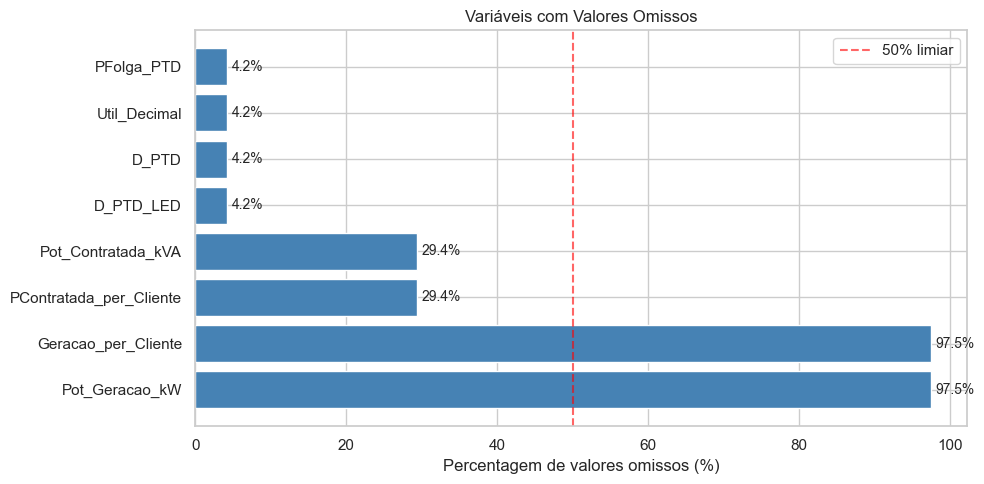

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Omissos': missing, 'Percentagem (%)': missing_pct})
missing_df = missing_df[missing_df['Valores Omissos'] > 0].sort_values('Percentagem (%)', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentagem (%)'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('Percentagem de valores omissos (%)')
ax.set_title('Variáveis com Valores Omissos')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% limiar')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Distribuição da Variável Categórica: Tipo Construtivo

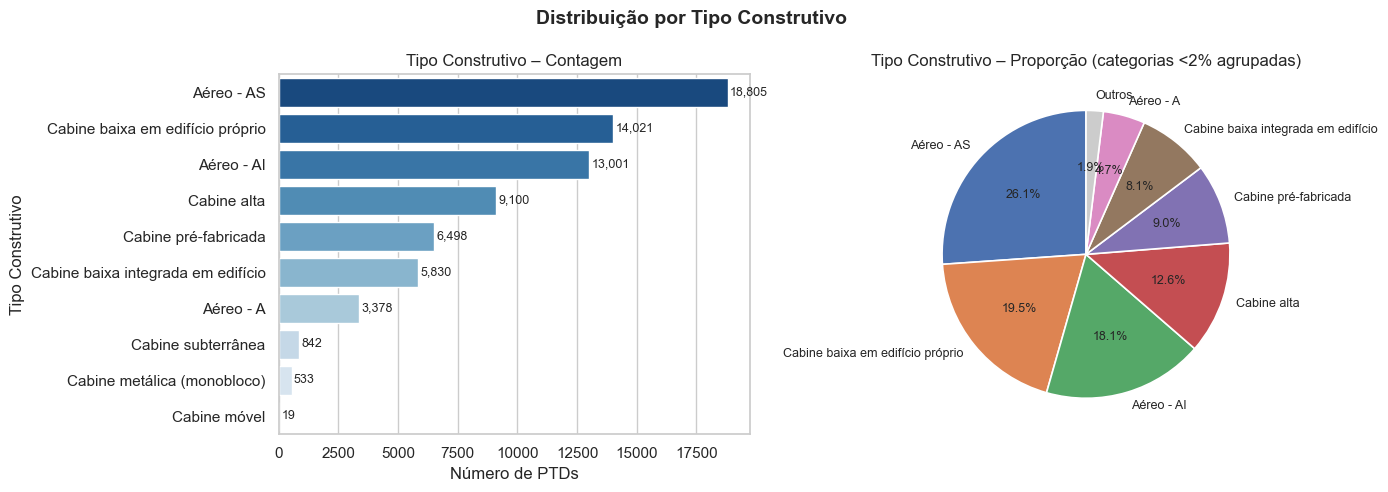

Categorias agrupadas em "Outros" (< 2% = < 1441 PTDs):
  - Cabine subterrânea: 842 PTDs (1.17%)
  - Cabine metálica (monobloco): 533 PTDs (0.74%)
  - Cabine móvel: 19 PTDs (0.03%)


In [6]:
tipo_counts = df['Tipo Construtivo'].value_counts()

# Agrupar categorias raras (< 2%) em "Outros"
threshold = 0.02 * tipo_counts.sum()
outros_sum = tipo_counts[tipo_counts < threshold].sum()
tipo_grouped = tipo_counts[tipo_counts >= threshold].copy()
tipo_grouped['Outros'] = outros_sum

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras (dados originais completos)
sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0],
            hue=tipo_counts.index, palette='Blues_r', legend=False)
axes[0].set_xlabel('Número de PTDs')
axes[0].set_title('Tipo Construtivo – Contagem')
for i, v in enumerate(tipo_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Gráfico circular (dados agrupados)
wedges, texts, autotexts = axes[1].pie(
    tipo_grouped.values,
    labels=tipo_grouped.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for i, label in enumerate(tipo_grouped.index):
    if label == 'Outros':
        wedges[i].set_facecolor('#cccccc')

axes[1].set_title('Tipo Construtivo – Proporção (categorias <2% agrupadas)')

plt.suptitle('Distribuição por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar o que foi agrupado
raras = tipo_counts[tipo_counts < threshold]
print(f'Categorias agrupadas em "Outros" (< 2% = < {threshold:.0f} PTDs):')
for nome, count in raras.items():
    print(f'  - {nome}: {count:,} PTDs ({count/tipo_counts.sum()*100:.2f}%)')

### 2.3 Distribuição do Nível de Utilização dos PTDs

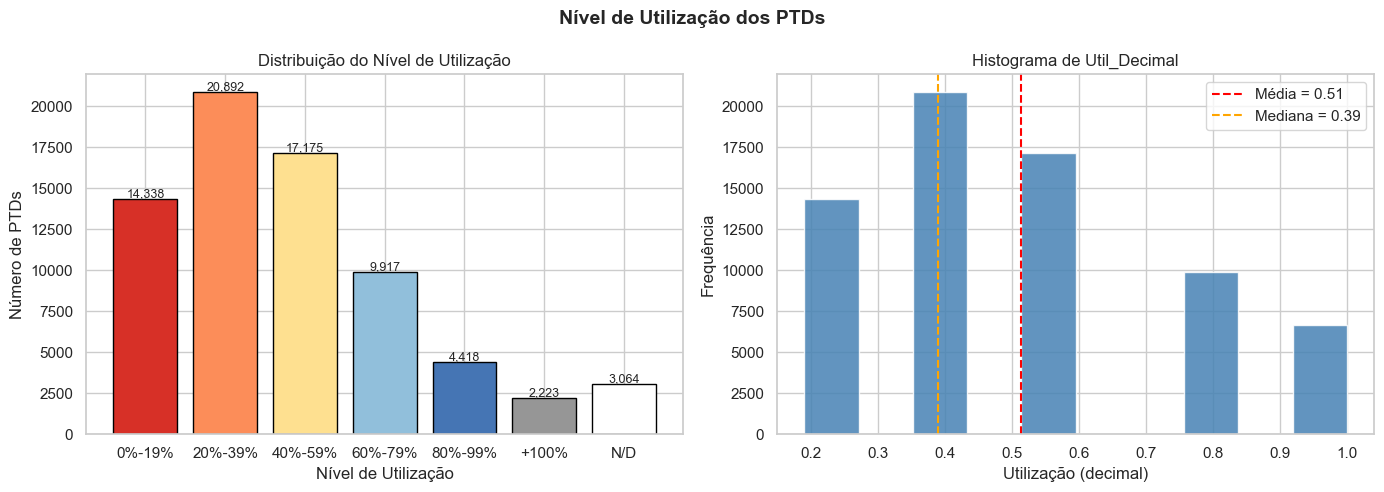

PTDs com utilização acima de 80%: 6,641 (9.6%)


In [7]:
util_col = [c for c in df.columns if 'Utiliza' in c][0]
util_counts = df[util_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por categoria
cores = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4', '#969696', '#ffffff']
cats_order = ['0%-19%', '20%-39%', '40%-59%', '60%-79%', '80%-99%', '+100%', 'N/D']
ordered = [util_counts.get(c, 0) for c in cats_order]
axes[0].bar(cats_order, ordered, color=cores[:len(cats_order)], edgecolor='black')
axes[0].set_xlabel('Nível de Utilização')
axes[0].set_ylabel('Número de PTDs')
axes[0].set_title('Distribuição do Nível de Utilização')
for i, v in enumerate(ordered):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Histograma de Util_Decimal (excluindo N/D)
util_dec = df['Util_Decimal'].dropna()
axes[1].hist(util_dec, bins=10, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(util_dec.mean(), color='red', linestyle='--', label=f'Média = {util_dec.mean():.2f}')
axes[1].axvline(util_dec.median(), color='orange', linestyle='--', label=f'Mediana = {util_dec.median():.2f}')
axes[1].set_xlabel('Utilização (decimal)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Util_Decimal')
axes[1].legend()

plt.suptitle('Nível de Utilização dos PTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PTDs com utilização acima de 80%: {(util_dec >= 0.8).sum():,} ({(util_dec >= 0.8).mean()*100:.1f}%)')

### 2.4 Distribuição das Variáveis Numéricas Principais

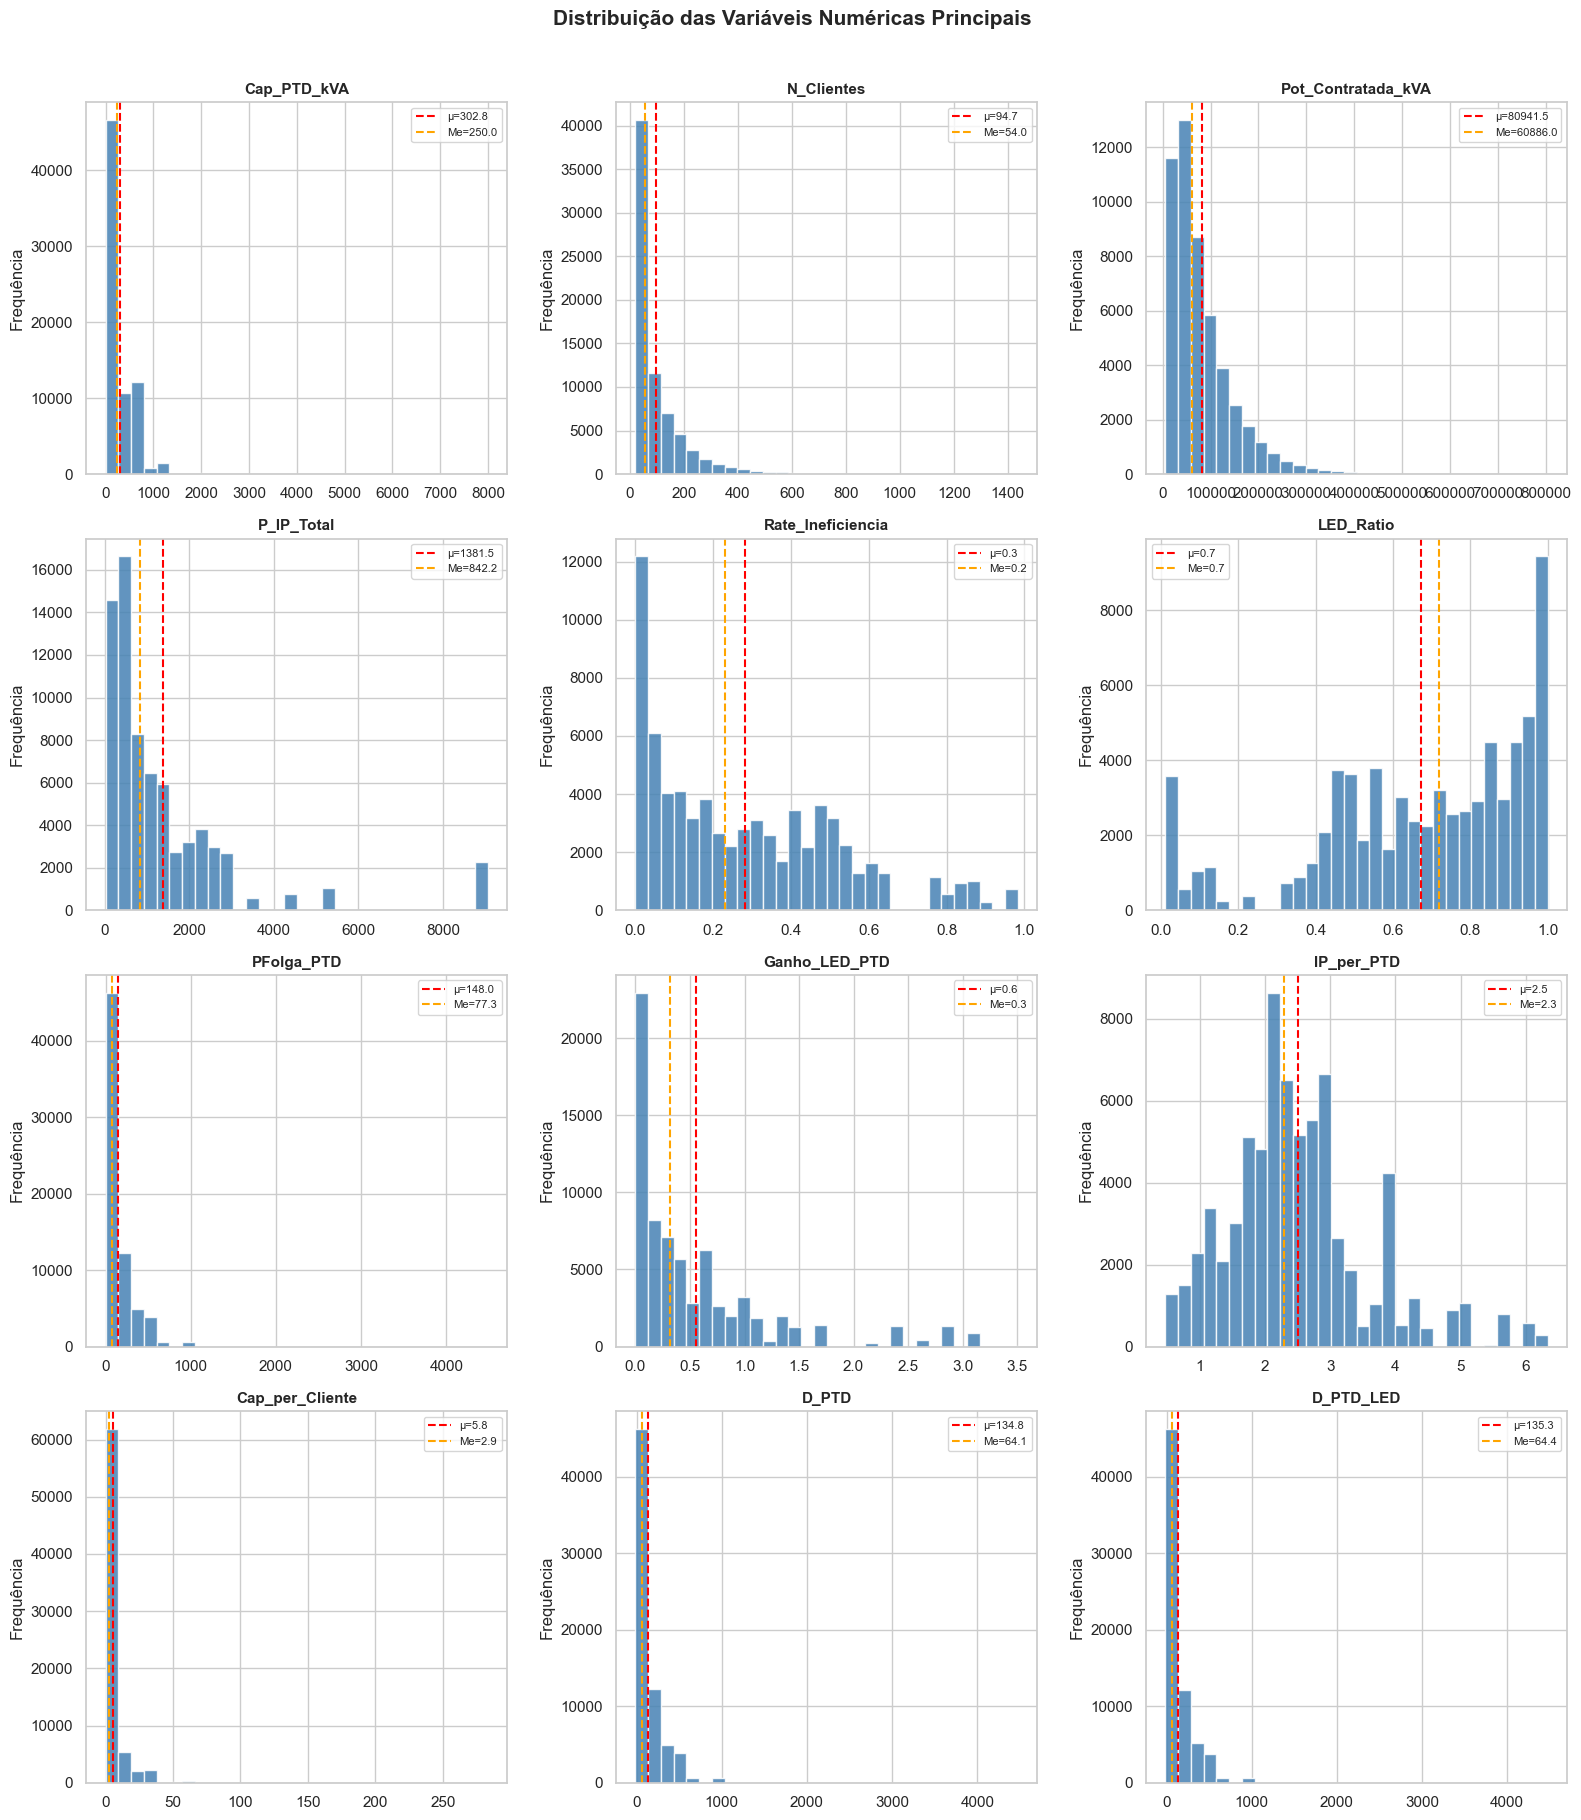

Assimetria (skewness) das variáveis principais:
Cap_per_Cliente       6.00
PFolga_PTD            3.77
D_PTD                 3.77
D_PTD_LED             3.76
Cap_PTD_kVA           3.41
P_IP_Total            3.00
N_Clientes            2.88
Pot_Contratada_kVA    2.14
Ganho_LED_PTD         1.97
IP_per_PTD            0.93
Rate_Ineficiencia     0.77
LED_Ratio            -0.83


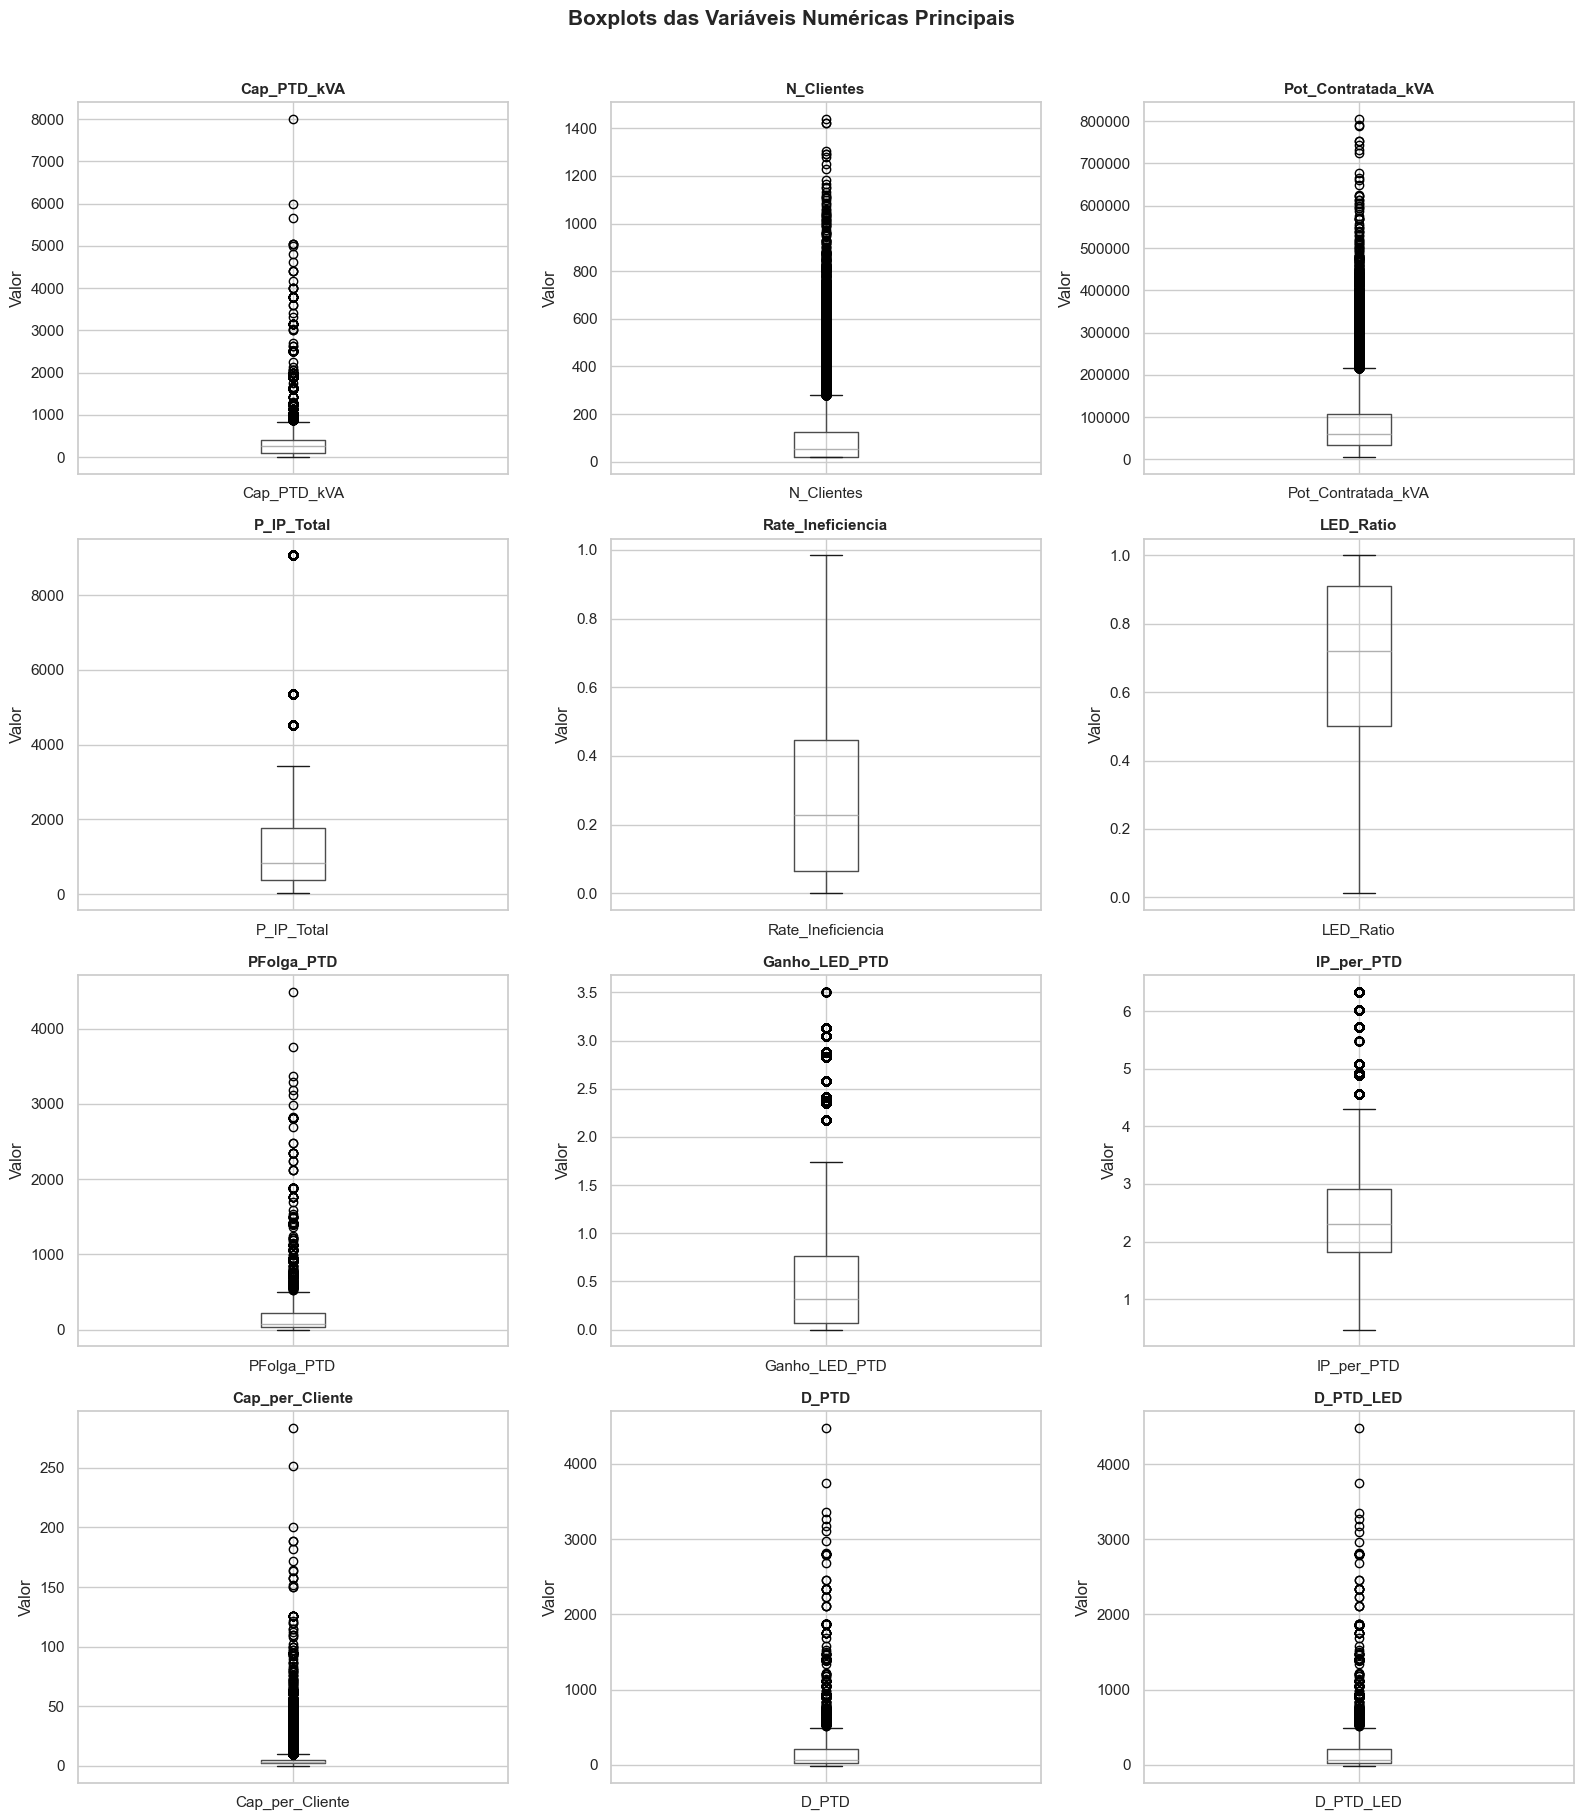

In [8]:
vars_principais = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'PFolga_PTD', 'Ganho_LED_PTD', 'IP_per_PTD',
    'Cap_per_Cliente', 'D_PTD', 'D_PTD_LED'
]

# ── Histogramas ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Me={data.median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Assimetria (skewness) ─────────────────────────────────────────────────────
print('Assimetria (skewness) das variáveis principais:')
skewness = df[vars_principais].skew().sort_values(ascending=False).round(2)
print(skewness.to_string())

# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[[col]].dropna()
    data.boxplot(ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Boxplots por Tipo Construtivo

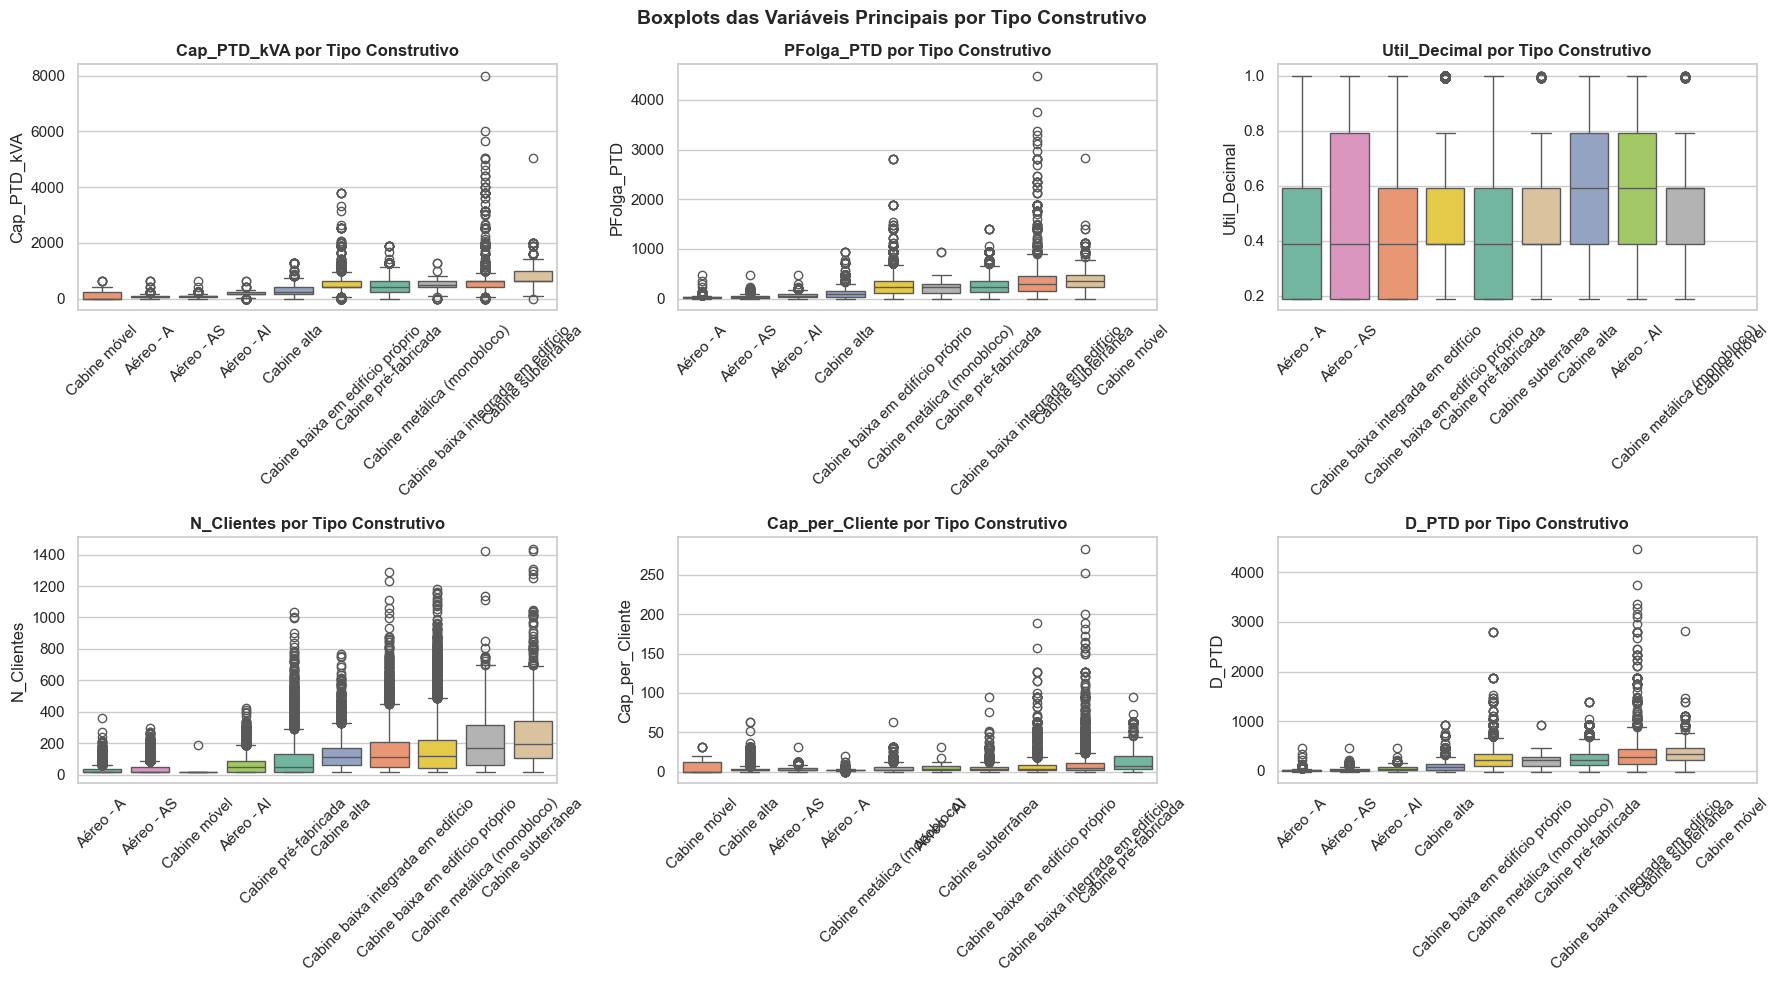

In [9]:
vars_boxplot = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal',
                'N_Clientes', 'Cap_per_Cliente', 'D_PTD']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    order = df.groupby('Tipo Construtivo')[col].median().sort_values().index
    sns.boxplot(
        data=df, x='Tipo Construtivo', y=col,
        ax=axes[i], palette='Set2',
        hue='Tipo Construtivo', legend=False,
        order=order
    )
    axes[i].set_title(f'{col} por Tipo Construtivo', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Boxplots das Variáveis Principais por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Matriz de Correlação

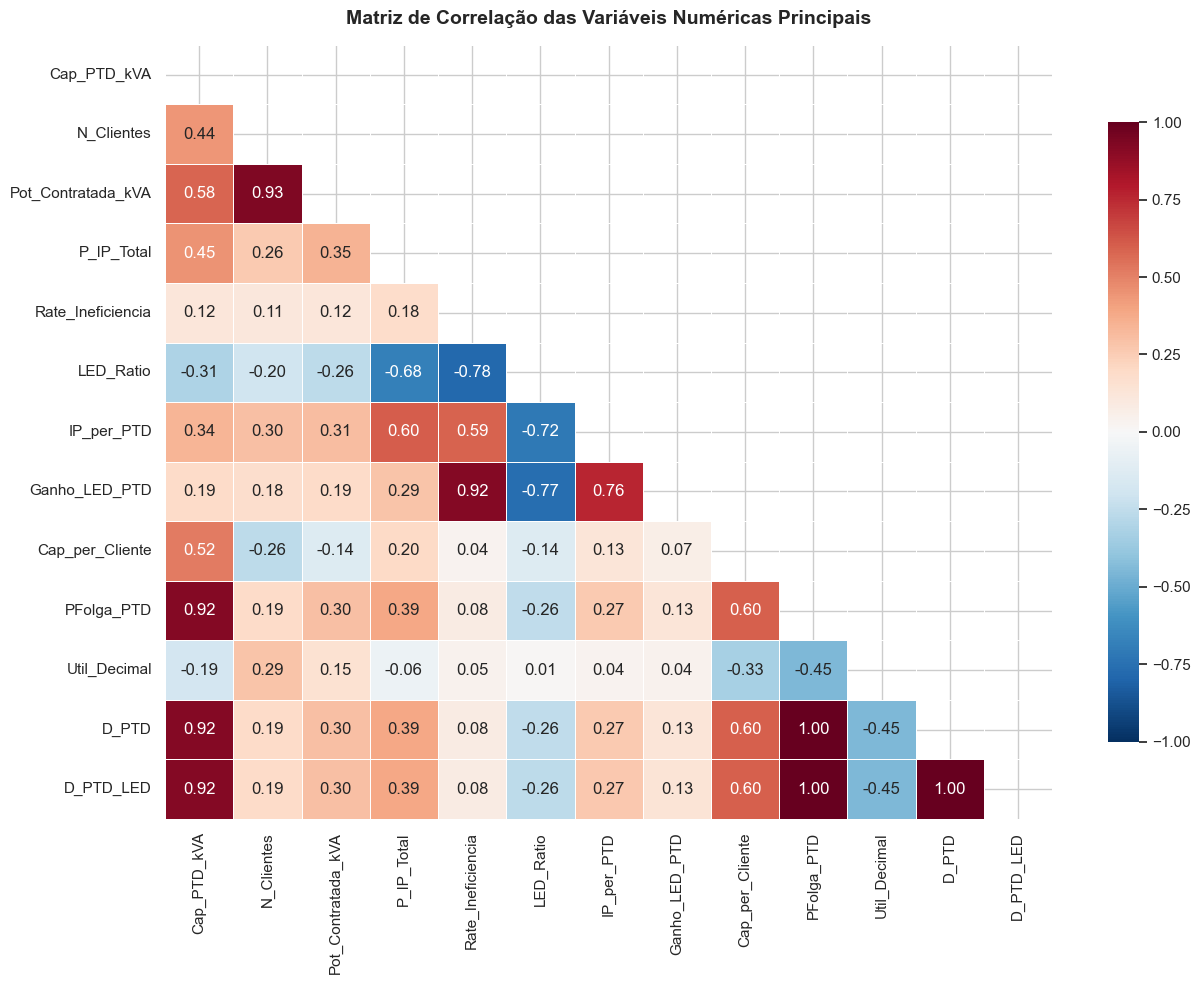

In [10]:
vars_corr = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente',
    'PFolga_PTD', 'Util_Decimal', 'D_PTD', 'D_PTD_LED'
]

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação das Variáveis Numéricas Principais', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.7 Relações-Chave entre Variáveis

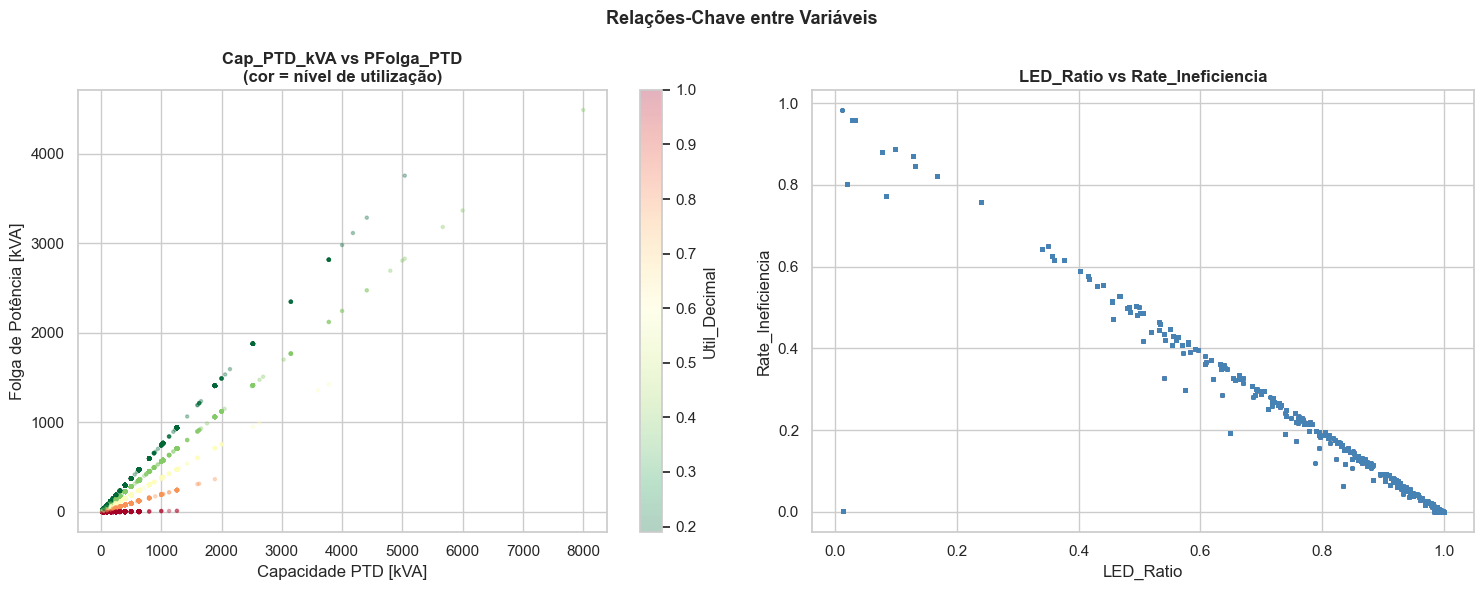

In [11]:
# Folga de Potência vs Capacidade do PTD — colorido por Tipo Construtivo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_data = df[['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio',
                    'Rate_Ineficiencia', 'Tipo Construtivo']].dropna()

# Scatter: Cap_PTD_kVA vs PFolga_PTD
sc1 = axes[0].scatter(
    scatter_data['Cap_PTD_kVA'], scatter_data['PFolga_PTD'],
    c=scatter_data['Util_Decimal'], cmap='RdYlGn_r',
    alpha=0.3, s=5
)
plt.colorbar(sc1, ax=axes[0], label='Util_Decimal')
axes[0].set_xlabel('Capacidade PTD [kVA]')
axes[0].set_ylabel('Folga de Potência [kVA]')
axes[0].set_title('Cap_PTD_kVA vs PFolga_PTD\n(cor = nível de utilização)', fontweight='bold')

# Scatter: LED_Ratio vs Rate_Ineficiencia
sc2 = axes[1].scatter(
    scatter_data['LED_Ratio'], scatter_data['Rate_Ineficiencia'],
    alpha=0.2, s=5, color='steelblue'
)
axes[1].set_xlabel('LED_Ratio')
axes[1].set_ylabel('Rate_Ineficiencia')
axes[1].set_title('LED_Ratio vs Rate_Ineficiencia', fontweight='bold')

plt.suptitle('Relações-Chave entre Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

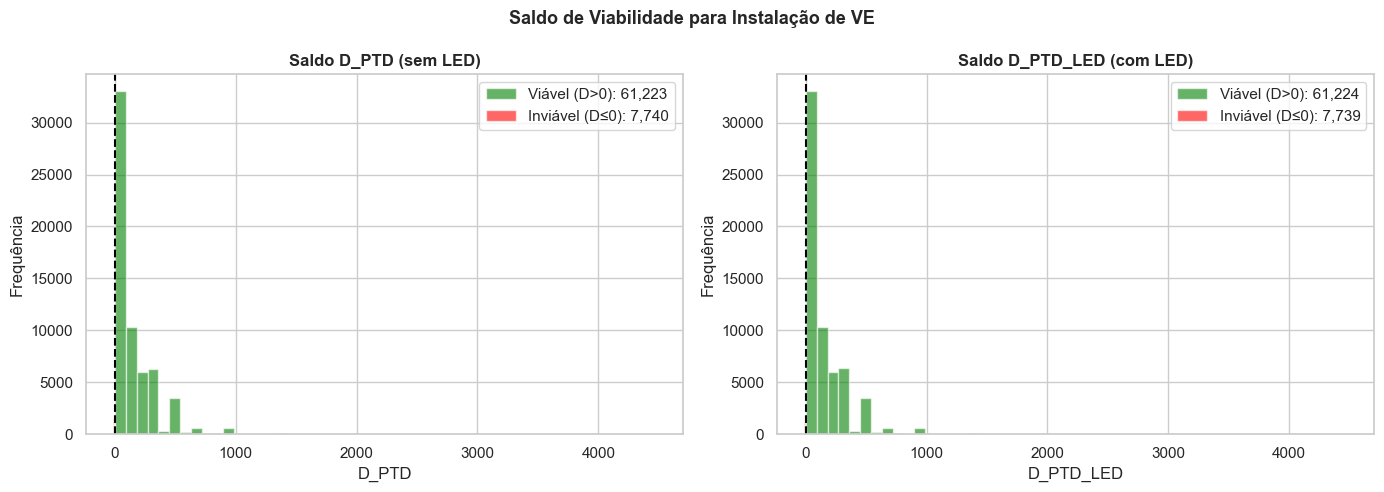

PTDs viáveis SEM LED:  61,223 / 68,963 (88.8%)
PTDs viáveis COM LED:  61,224 / 68,963 (88.8%)


In [12]:
# Distribuição de D_PTD e D_PTD_LED — Viabilidade de VE
d_data = df[['D_PTD', 'D_PTD_LED']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['D_PTD', 'D_PTD_LED'],
                           ['Saldo D_PTD (sem LED)', 'Saldo D_PTD_LED (com LED)']):
    data = d_data[col]
    pos = (data > 0).sum()
    neg = (data <= 0).sum()
    ax.hist(data[data > 0], bins=50, color='green', alpha=0.6, label=f'Viável (D>0): {pos:,}')
    ax.hist(data[data <= 0], bins=30, color='red', alpha=0.6, label=f'Inviável (D≤0): {neg:,}')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Saldo de Viabilidade para Instalação de VE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total = len(d_data)
print(f'PTDs viáveis SEM LED:  {(d_data["D_PTD"] > 0).sum():,} / {total:,} ({(d_data["D_PTD"] > 0).mean()*100:.1f}%)')
print(f'PTDs viáveis COM LED:  {(d_data["D_PTD_LED"] > 0).sum():,} / {total:,} ({(d_data["D_PTD_LED"] > 0).mean()*100:.1f}%)')

---
## 3. Pré-processamento dos Dados
### 3.1 Tratamento de Valores Omissos

In [13]:
df_clean = df.copy()

# Pot_Geracao_kW e Geracao_per_Cliente: ~97% de valores omissos → remover colunas
cols_drop_missing = ['Pot_Geracao_kW', 'Geracao_per_Cliente']
df_clean.drop(columns=cols_drop_missing, inplace=True)
print(f'Colunas removidas por excesso de valores omissos (>95%): {cols_drop_missing}')

# Nível de Utilização com valor "N/D" corresponde às mesmas linhas com PFolga_PTD = NaN
# Remover registos sem PFolga_PTD (não é possível calcular métricas principais)
n_antes = len(df_clean)
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)
print(f'Registos removidos (PFolga_PTD/Util indefinido): {n_antes - len(df_clean):,}')
print(f'Registos restantes: {len(df_clean):,}')

# Pot_Contratada_kVA: ~29% de valores omissos → imputar com mediana por Tipo Construtivo
df_clean['Pot_Contratada_kVA'] = df_clean.groupby('Tipo Construtivo')['Pot_Contratada_kVA'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['PContratada_per_Cliente'] = df_clean.groupby('Tipo Construtivo')['PContratada_per_Cliente'].transform(
    lambda x: x.fillna(x.median())
)
print(f'\nValores omissos restantes:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Colunas removidas por excesso de valores omissos (>95%): ['Pot_Geracao_kW', 'Geracao_per_Cliente']
Registos removidos (PFolga_PTD/Util indefinido): 3,064
Registos restantes: 68,963

Valores omissos restantes:
Series([], dtype: int64)


### 3.2 Transformação de Variáveis Categóricas

In [14]:
# Tipo Construtivo - One-Hot Encoding (todas as categorias, sem agrupamento)
print('Categorias de Tipo Construtivo:')
print(df_clean['Tipo Construtivo'].value_counts().to_string())

df_clean = pd.get_dummies(df_clean, columns=['Tipo Construtivo'], drop_first=False, dtype=int)
cols_ohe_tipo = [c for c in df_clean.columns if 'Tipo Construtivo' in c]
n_tipo = len(cols_ohe_tipo)
print('Colunas OHE Tipo Construtivo (' + str(n_tipo) + '):', cols_ohe_tipo)

# Distrito - One-Hot Encoding
n_dist = df_clean['Distrito'].nunique()
print('Distritos unicos:', n_dist)
print(df_clean['Distrito'].value_counts().to_string())

df_clean = pd.get_dummies(df_clean, columns=['Distrito'], drop_first=False, dtype=int)
cols_ohe_dist = [c for c in df_clean.columns if c.startswith('Distrito_')]
n_dist_cols = len(cols_ohe_dist)
print('Colunas OHE Distrito (' + str(n_dist_cols) + '):', cols_ohe_dist)


Categorias de Tipo Construtivo:
Tipo Construtivo
Aéreo - AS                            17888
Cabine baixa em edifício próprio      13486
Aéreo - AI                            12359
Cabine alta                            8844
Cabine pré-fabricada                   6119
Cabine baixa integrada em edifício     5655
Aéreo - A                              3269
Cabine subterrânea                      829
Cabine metálica (monobloco)             514
Colunas OHE Tipo Construtivo (9): ['Tipo Construtivo_Aéreo - A', 'Tipo Construtivo_Aéreo - AI', 'Tipo Construtivo_Aéreo - AS', 'Tipo Construtivo_Cabine alta', 'Tipo Construtivo_Cabine baixa em edifício próprio', 'Tipo Construtivo_Cabine baixa integrada em edifício', 'Tipo Construtivo_Cabine metálica (monobloco)', 'Tipo Construtivo_Cabine pré-fabricada', 'Tipo Construtivo_Cabine subterrânea']
Distritos unicos: 18
Distrito
Porto               8725
Lisboa              8490
Braga               4992
Faro                4974
Santarém            4488
Setúb

### 3.3 Seleção de Variáveis Relevantes

In [15]:
# Criterios de remocao:
# [Identificadores]    : Concelho, Codigo de Instalacao, Coordenadas Geograficas, CodDistritoConcelho
# [Data leakage]       : D_PTD, D_PTD_LED
# [Constante]          : PVE_PTD
# [Duplicado]          : Potencia instalada [kVA]
# [97% omissos]        : Pot_Geracao_kW, Geracao_per_Cliente
# [Redundante]         : Nivel de Utilizacao [%]
# [Multicolinearidade] : N_Lampadas, IP_Inef_per_PTD

pot_col      = [c for c in df_clean.columns if 'instalada' in c][0]
util_col_str = [c for c in df_clean.columns if 'Utiliza' in c][0]
cod_col      = [c for c in df_clean.columns if 'digo' in c][0]
coord_col    = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Concelho', 'CodDistritoConcelho', cod_col, coord_col,
    'D_PTD', 'D_PTD_LED',
    'PVE_PTD',
    pot_col,
    util_col_str,
    'N_Lampadas', 'IP_Inef_per_PTD',
]

cols_rem = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_rem)

print('Variaveis removidas (' + str(len(cols_rem)) + '):')
for c in cols_rem:
    print('  - ' + c)

print('Total variaveis finais: ' + str(df_model.shape[1]))
print('Variaveis selecionadas:')
for c in df_model.columns:
    print('  ' + c + '  (' + str(df_model[c].dtype) + ')')


Variaveis removidas (11):
  - Concelho
  - CodDistritoConcelho
  - Código de Instalação
  - Coordenadas Geográficas
  - D_PTD
  - D_PTD_LED
  - PVE_PTD
  - Potência instalada [kVA]
  - Nível de Utilização [%]
  - N_Lampadas
  - IP_Inef_per_PTD
Total variaveis finais: 44
Variaveis selecionadas:
  Cap_PTD_kVA  (int64)
  Pot_Contratada_kVA  (float64)
  N_Clientes  (int64)
  N_Clientes_Produtores  (int64)
  P_IP_Total  (float64)
  P_IP_Inef  (float64)
  Rate_Ineficiencia  (float64)
  LED_Ratio  (float64)
  N_Luminarias  (int64)
  N_PTDs_Concelho  (int64)
  IP_per_PTD  (float64)
  Ganho_LED_PTD  (float64)
  Cap_per_Cliente  (float64)
  PContratada_per_Cliente  (float64)
  Clientes_Produtores_Ratio  (float64)
  Util_Decimal  (float64)
  PFolga_PTD  (float64)
  Tipo Construtivo_Aéreo - A  (int64)
  Tipo Construtivo_Aéreo - AI  (int64)
  Tipo Construtivo_Aéreo - AS  (int64)
  Tipo Construtivo_Cabine alta  (int64)
  Tipo Construtivo_Cabine baixa em edifício próprio  (int64)
  Tipo Construtivo_C

### 3.4 Normalização / Standardização

In [16]:
cols_ohe = [c for c in df_model.columns if 'Tipo Construtivo' in c or c.startswith('Distrito_')]

cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns
                  if c not in cols_ohe]

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df_model[cols_numericas])

print('Variaveis NAO normalizadas (OHE - ' + str(len(cols_ohe)) + '):')
print(cols_ohe)

print('Variaveis normalizadas (' + str(len(cols_numericas)) + '):')
print(cols_numericas)

print('Estatisticas apos normalizacao (media=0, std=1):')
print(df_scaled[cols_numericas].describe().loc[['mean', 'std']].round(4).T)

print('Nota: na modelacao o fit sera feito apenas nos dados de treino.')


Variaveis NAO normalizadas (OHE - 27):
['Tipo Construtivo_Aéreo - A', 'Tipo Construtivo_Aéreo - AI', 'Tipo Construtivo_Aéreo - AS', 'Tipo Construtivo_Cabine alta', 'Tipo Construtivo_Cabine baixa em edifício próprio', 'Tipo Construtivo_Cabine baixa integrada em edifício', 'Tipo Construtivo_Cabine metálica (monobloco)', 'Tipo Construtivo_Cabine pré-fabricada', 'Tipo Construtivo_Cabine subterrânea', 'Distrito_Aveiro', 'Distrito_Beja', 'Distrito_Braga', 'Distrito_Bragança', 'Distrito_Castelo Branco', 'Distrito_Coimbra', 'Distrito_Faro', 'Distrito_Guarda', 'Distrito_Leiria', 'Distrito_Lisboa', 'Distrito_Portalegre', 'Distrito_Porto', 'Distrito_Santarém', 'Distrito_Setúbal', 'Distrito_Viana do Castelo', 'Distrito_Vila Real', 'Distrito_Viseu', 'Distrito_Évora']
Variaveis normalizadas (17):
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'N_Clientes_Produtores', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_PTDs_Concelho', 'IP_per_PTD', 'Ganho_LED_PTD', 'C

---
## 4. Sumário Final do Dataset Pré-processado

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# RESUMO DO PRÉ-PROCESSAMENTO
# ─────────────────────────────────────────────────────────────────────────────

SEP = '=' * 70

print(SEP)
print('  RESUMO DO PRÉ-PROCESSAMENTO')
print(SEP)
print(f'  Dataset original :   {df.shape[0]:>7,} registos  ×  {df.shape[1]:>2} variáveis')
print(f'  Após limpeza     :   {df_model.shape[0]:>7,} registos  ×  {df_model.shape[1]:>2} variáveis')
print(f'  Registos removidos : {df.shape[0] - df_model.shape[0]:>7,}  ({(df.shape[0]-df_model.shape[0])/df.shape[0]*100:.1f}%)')
print(f'  Valores omissos restantes: {df_model.isnull().sum().sum()}')
print(SEP)

# ── 1. COLUNAS REMOVIDAS ──────────────────────────────────────────────────────
print('\n[1] COLUNAS REMOVIDAS E JUSTIFICAÇÃO\n')

removidas = {
    # Identificadores / administrativas
    'Distrito'                   : 'Identificador geográfico administrativo — sem valor preditivo para o PTD.',
    'Concelho'                   : 'Identificador geográfico administrativo — sem valor preditivo para o PTD.',
    'CodDistritoConcelho'        : 'Código numérico do concelho — identificador, não feature.',
    'Código de Instalação'       : 'Chave primária do PTD — não contém informação preditiva.',
    'Coordenadas Geográficas'    : 'String de texto (lat/lon) não tratada; espacialidade não modelada nesta fase.',
    'N_PTDs_Concelho'            : 'Característica do concelho, não do PTD individual; não acrescenta discriminação.',
    # Constante
    'PVE_PTD'                    : 'Variável constante (13,2 kW em todos os registos) — variância = 0, sem poder discriminativo.',
    # Redundante / colinear
    'Potência instalada [kVA]'   : 'Cópia exata de Cap_PTD_kVA (correlação = 1,0) — removida para evitar multicolinearidade.',
    'Nível de Utilização [%]'    : 'Variável categórica textual substituída por Util_Decimal (contínua) e Util_Ordinal (ordinal).',
    'N_Luminarias'               : 'Quantidade de luminárias do concelho; informação já resumida em P_IP_Total e LED_Ratio.',
    'N_Lampadas'                 : 'Análoga a N_Luminarias — colinear e redundante.',
    'P_IP_Inef'                  : 'Colinear com IP_per_PTD × Rate_Ineficiencia; capturada por essas duas features.',
    'IP_Inef_per_PTD'            : 'Derivada direta de IP_per_PTD e Rate_Ineficiencia — redundante.',
    'N_Clientes_Produtores'      : 'Valores maioritariamente = 20 (valor mínimo por defeito) — variabilidade negligenciável.',
    'Clientes_Produtores_Ratio'  : 'Derivada de N_Clientes_Produtores / N_Clientes — herda a mesma limitação.',
    # Excesso de omissos
    'Pot_Geracao_kW'             : '97,5 % de valores omissos — imputação não seria fiável; coluna removida.',
    'Geracao_per_Cliente'        : '97,5 % de valores omissos — derivada de Pot_Geracao_kW; idem.',
    # Data leakage
    'D_PTD'                      : 'Derivada direta de PFolga_PTD − PVE_PTD — causaria data leakage nos modelos.',
    'D_PTD_LED'                  : 'Derivada de D_PTD + Ganho_LED_PTD — idem.',
    # Remoção de registos
    'Linhas com Util = N/D'      : '3 064 registos sem PFolga_PTD / Util_Decimal definidos — removidos (4,3 % do total).',
}

for col, justif in removidas.items():
    print(f'  ✗ {col:<35} → {justif}')

# ── 2. COLUNAS ADICIONADAS ────────────────────────────────────────────────────
print(f'\n{SEP}')
print('\n[2] COLUNAS ADICIONADAS / CRIADAS\n')

adicionadas = {
    'Util_Ordinal'                                       : 'Mapeamento ordinal de "Nível de Utilização [%]" (1–6) — preserva ordem lógica das classes.',
    'PTD_Saturado'                                       : 'Variável binária: 1 se Util_Decimal ≥ 0,8 (saturado), 0 caso contrário — alvo para classificação.',
    'Tipo Construtivo_Aéreo - AI'                        : 'OHE de "Tipo Construtivo": indica PTD do tipo Aéreo - AI.',
    'Tipo Construtivo_Aéreo - AS'                        : 'OHE de "Tipo Construtivo": indica PTD do tipo Aéreo - AS.',
    'Tipo Construtivo_Cabine alta'                       : 'OHE de "Tipo Construtivo": indica Cabine alta.',
    'Tipo Construtivo_Cabine baixa em edifício próprio'  : 'OHE de "Tipo Construtivo": indica Cabine baixa em edifício próprio.',
    'Tipo Construtivo_Cabine baixa integrada em edifício': 'OHE de "Tipo Construtivo": indica Cabine baixa integrada em edifício.',
    'Tipo Construtivo_Cabine pré-fabricada'              : 'OHE de "Tipo Construtivo": indica Cabine pré-fabricada.',
    'Tipo Construtivo_Outros'                            : 'OHE: agrupa categorias raras (<2 % dos PTDs) — Cabine subterrânea e Cabine metálica.',
}

print('  Nota: one-hot encoding com drop_first=True (categoria base omitida automaticamente).')
print()
for col, justif in adicionadas.items():
    print(f'  ✚ {col:<55} → {justif}')

# ── 3. VARIÁVEIS FINAIS ───────────────────────────────────────────────────────
print(f'\n{SEP}')
print(f'\n[3] VARIÁVEIS FINAIS ({df_model.shape[1]}) E PAPEL NA ANÁLISE\n')

vars_desc = {
    'Cap_PTD_kVA'               : '[PTD] Capacidade instalada do transformador (kVA). Feature central da capacidade disponível.',
    'Pot_Contratada_kVA'        : '[PTD] Potência contratada pelos clientes (kVA). Indica carga efetiva registada.',
    'N_Clientes'                : '[PTD] Número de clientes ligados. Proxy da carga residencial/comercial.',
    'Cap_per_Cliente'           : '[PTD] Capacidade por cliente (kVA/cliente). Normaliza a capacidade pelo número de ligações.',
    'PContratada_per_Cliente'   : '[PTD] Potência contratada por cliente. Captura perfil de consumo médio por ligação.',
    'P_IP_Total'                : '[IP] Potência total de iluminação pública no concelho (W). Volume absoluto de carga de IP.',
    'Rate_Ineficiencia'         : '[IP] Fração de luminárias ineficientes. Mede o potencial de melhoria via substituição LED.',
    'LED_Ratio'                 : '[IP] Fração de luminárias já convertidas para LED. Complemento de Rate_Ineficiencia.',
    'IP_per_PTD'                : '[IP] Potência de IP atribuída por PTD (kW/PTD). Distribui a carga de IP por posto.',
    'Ganho_LED_PTD'             : '[IP] Redução de carga estimada por conversão total para LED, por PTD (kW). Quantifica o ganho.',
    'Util_Decimal'              : '[Alvo/Feature] Utilização do PTD em decimal [0,1]. Variável contínua de carga relativa.',
    'Util_Ordinal'              : '[Alvo/Feature] Nível de utilização codificado ordinalmente (1=0–19% … 6=+100%).',
    'PTD_Saturado'              : '[Alvo binário] 1 se utilização ≥ 80% — variável alvo para classificação de saturação.',
    'PFolga_PTD'                : '[Alvo regressão] Folga de potência disponível no PTD (kVA). Variável alvo principal.',
    'Tipo Construtivo_Aéreo - AI'                        : '[Tipo] OHE — PTD do tipo Aéreo integrado.',
    'Tipo Construtivo_Aéreo - AS'                        : '[Tipo] OHE — PTD do tipo Aéreo simples.',
    'Tipo Construtivo_Cabine alta'                       : '[Tipo] OHE — Cabine alta.',
    'Tipo Construtivo_Cabine baixa em edifício próprio'  : '[Tipo] OHE — Cabine baixa em edifício próprio.',
    'Tipo Construtivo_Cabine baixa integrada em edifício': '[Tipo] OHE — Cabine baixa integrada em edifício.',
    'Tipo Construtivo_Cabine pré-fabricada'              : '[Tipo] OHE — Cabine pré-fabricada.',
    'Tipo Construtivo_Outros'                            : '[Tipo] OHE — Categorias raras agrupadas (<2%).',
}

for col in df_model.columns:
    desc = vars_desc.get(col, '—')
    print(f'  • {col:<55} {desc}')

print(f'\n{SEP}')
print(f'  df_model  (sem normalização) : {df_model.shape}')
print(f'  df_scaled (StandardScaler)   : {df_scaled.shape}')
print(SEP)

  RESUMO DO PRÉ-PROCESSAMENTO
  Dataset original :    72,027 registos  ×  32 variáveis
  Após limpeza     :    68,963 registos  ×  44 variáveis
  Registos removidos :   3,064  (4.3%)
  Valores omissos restantes: 0

[1] COLUNAS REMOVIDAS E JUSTIFICAÇÃO

  ✗ Distrito                            → Identificador geográfico administrativo — sem valor preditivo para o PTD.
  ✗ Concelho                            → Identificador geográfico administrativo — sem valor preditivo para o PTD.
  ✗ CodDistritoConcelho                 → Código numérico do concelho — identificador, não feature.
  ✗ Código de Instalação                → Chave primária do PTD — não contém informação preditiva.
  ✗ Coordenadas Geográficas             → String de texto (lat/lon) não tratada; espacialidade não modelada nesta fase.
  ✗ N_PTDs_Concelho                     → Característica do concelho, não do PTD individual; não acrescenta discriminação.
  ✗ PVE_PTD                             → Variável constante (13,2 kW em 

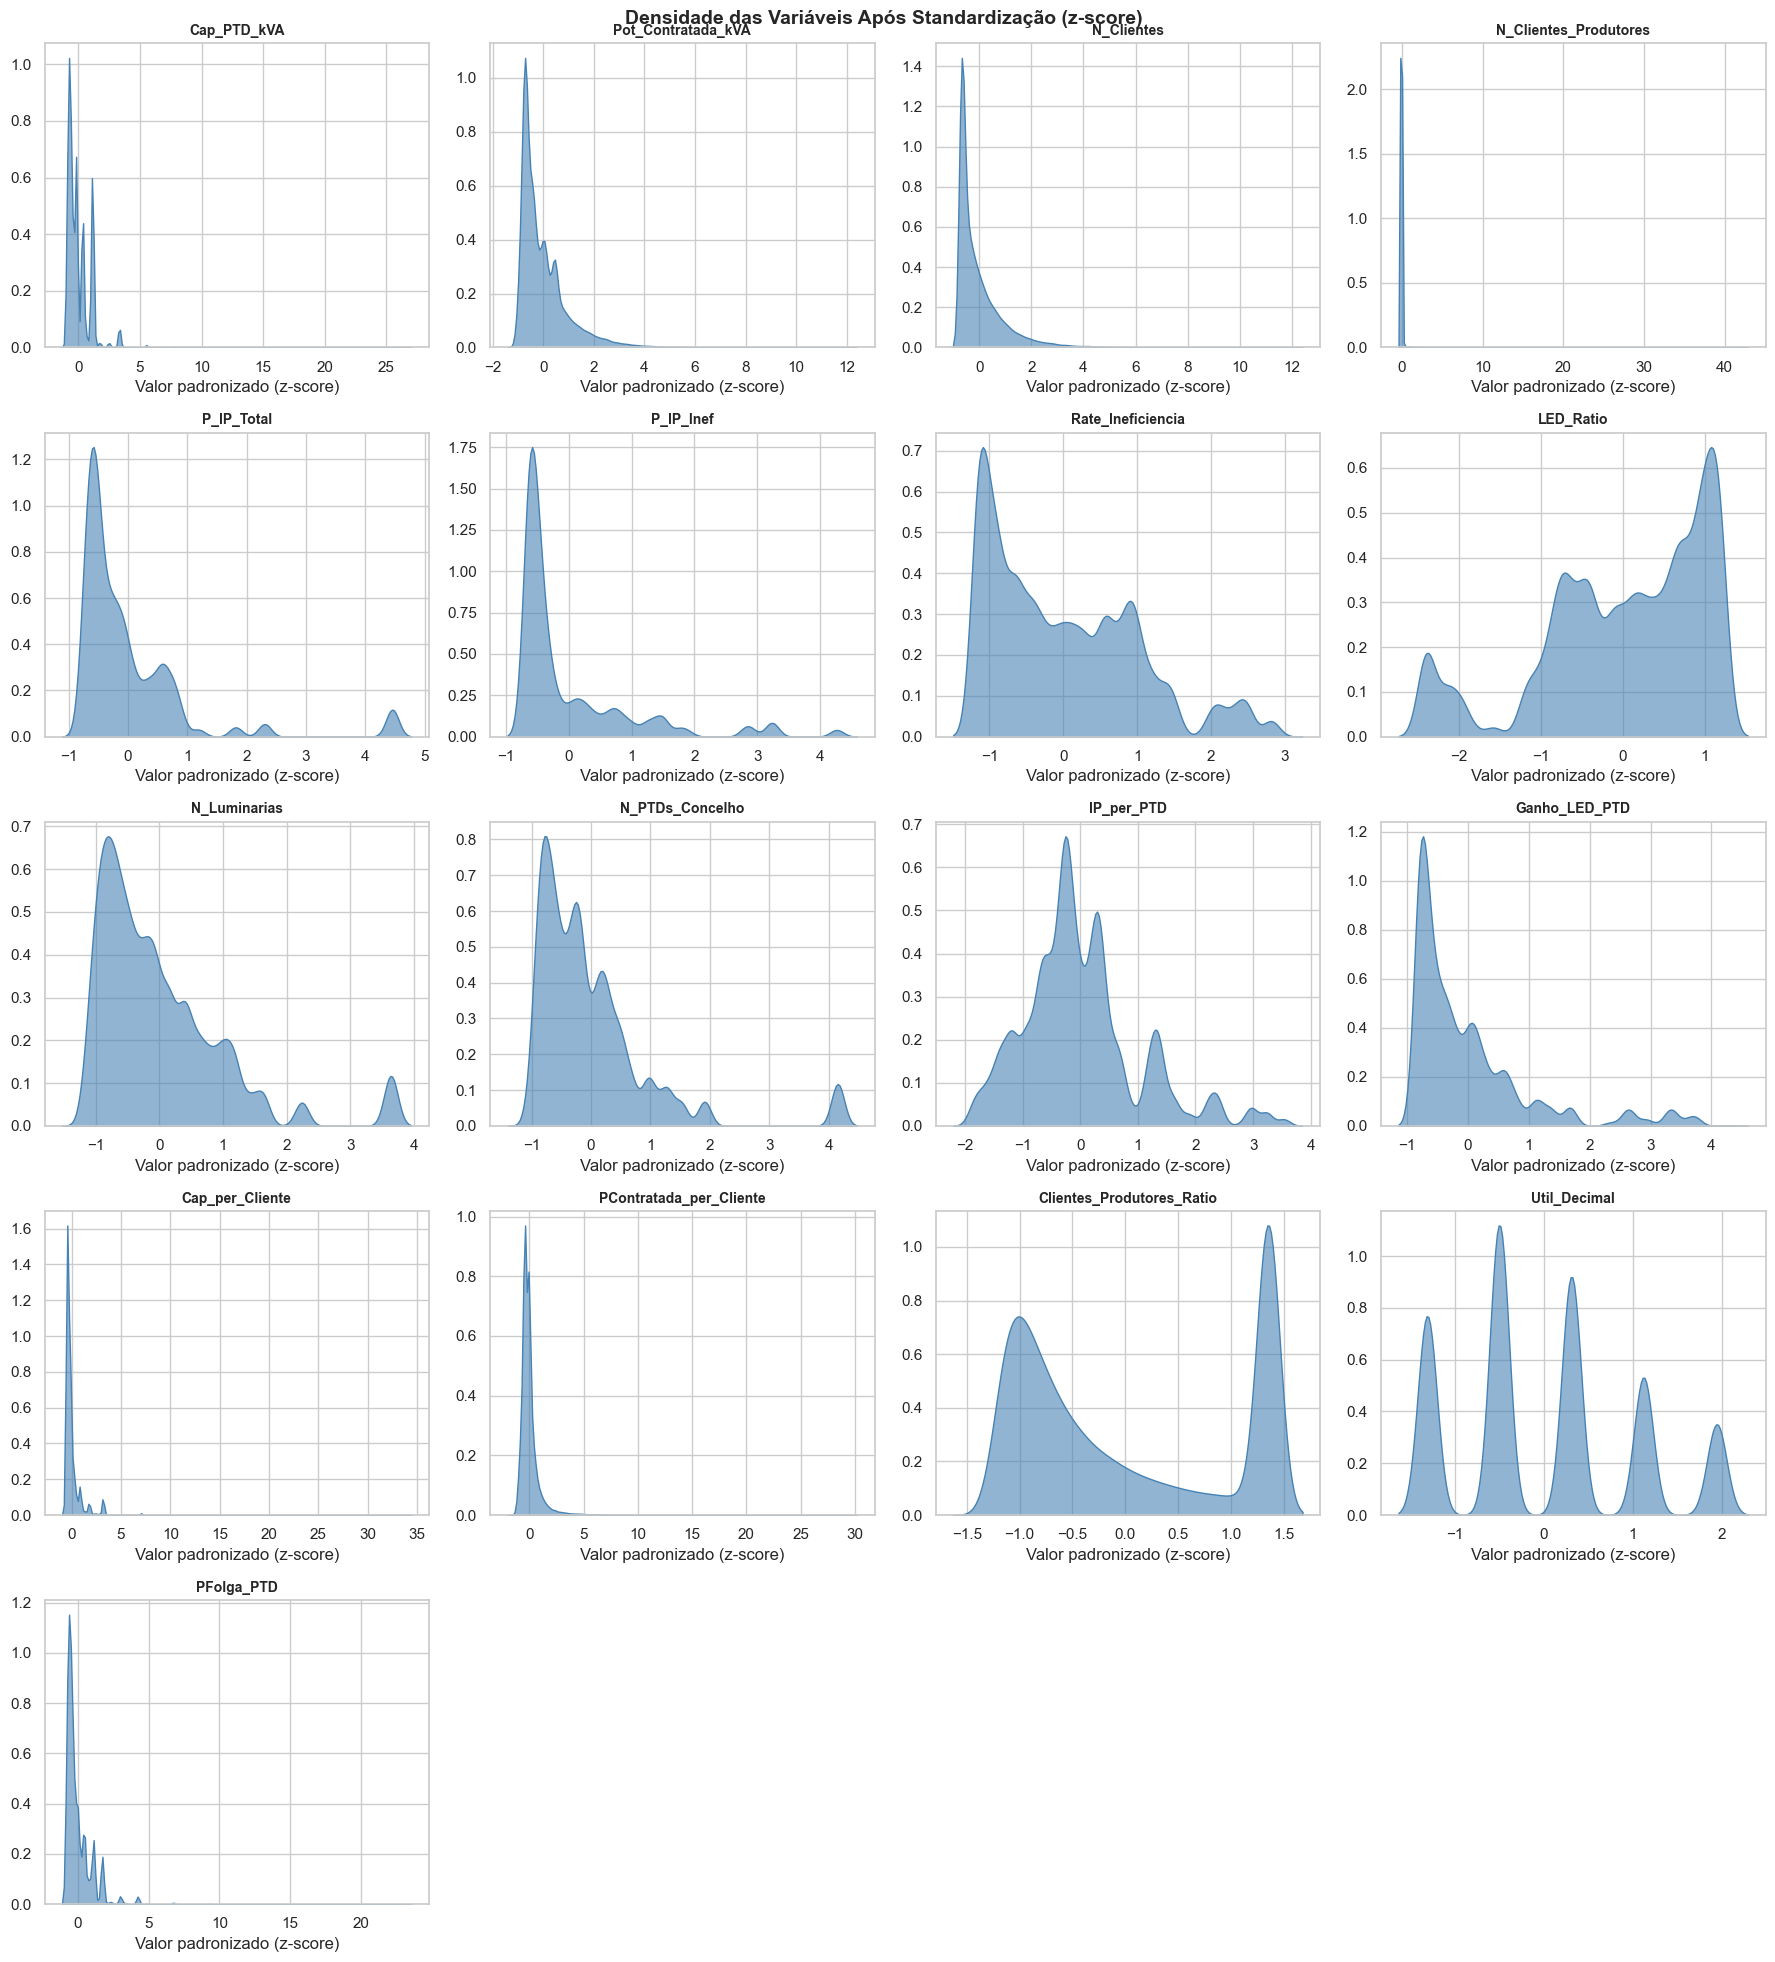

Variáveis representadas: 17
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'N_Clientes_Produtores', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_PTDs_Concelho', 'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Clientes_Produtores_Ratio', 'Util_Decimal', 'PFolga_PTD']


In [18]:
# Visualização final: distribuição das variáveis numéricas após standardização
cols_ohe = [c for c in df_model.columns if 'Tipo Construtivo' in c or c.startswith('Distrito_')]
cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns if c not in cols_ohe]

n = len(cols_numericas)
ncols = 4
nrows = -(-n // ncols)  # arredonda para cima

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.kdeplot(df_scaled[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor padronizado (z-score)')
    axes[i].set_ylabel('')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Densidade das Variáveis Após Standardização (z-score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Variáveis representadas: {n}')
print(cols_numericas)